In [33]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader 

import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), # Known mean
        (0.2470, 0.2435, 0.2616)) # Known std
])

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
    transforms.StandardJitter

])

In [35]:
def get_dataloaders(batch_size: int=64):
    """
    Function defines the transform which converts to Tensor and Normalizes
    Function downloads and stores the dataset if not already downloaded
    Function then uses Dataloader to create batches
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), # Known mean
            (0.2470, 0.2435, 0.2616)) # Known std
        ])
    
    train_data = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True, # May learn artificial artifacts if False
        num_workers=2,
        pin_memory=True,
        # persistent_workers=True   See if needed
        # drop_last=True            Could also add if needed
        )
    
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"\nDataset sizes -> train: {len(train_data):,} | test: {len(test_data):,}")
    print(f"Batches -> train: {len(train_loader):,} | test: {len(test_loader):,}")

    return train_loader, test_loader

train_loader, test_loader = get_dataloaders()


Dataset sizes -> train: 50,000 | test: 10,000
Batches -> train: 782 | test: 157


In [36]:
# Define the architecture we will be using (Attempting ResNet)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None

        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = self.relu(out)
        

        return out

In [37]:
class ResNet(nn.Module):
    def __init__(self, block, layers, in_channels=3, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)  
        x = self.fc(x)

        return x    


    def _make_layer(self, block, out_channels, num_blocks, stride=1):
        """
        block: chooses the block class to use
        out_channels: target channels for this stage of the architecture
        num_blocks: defines how many residual blocks to stack
        """
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        for i in range(num_blocks - 1):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

In [38]:
model = ResNet(ResidualBlock, [2, 2, 2, 2])

x = torch.randn(4, 3, 32, 32)

output = model(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])


In [39]:
# Train epoch

def train_epoch(model, loader, criterion, optimizer, epoch, num_epochs):    
    model.train() # Set into train mode
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        
        # Updating loss, correct, and total
        running_loss += loss.item() * images.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)    

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch: {epoch}/{num_epochs}")
            print(f"Step: {batch_idx+1}/{len(loader)}")
            print(f"Loss: {running_loss / (batch_idx + 1)}\n")
    
    accuracy = correct / total
    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        loss = criterion(output, labels)

        running_loss += loss.item() * images.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [40]:
# Training loop

# Move model to device
def train(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=10):
    model.to(device)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(
            model, 
            train_loader,
            criterion,
            optimizer,
            epoch,
            num_epochs
        )
        val_loss, val_acc = evaluate(
            model, 
            test_loader, 
            criterion
        )

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Train loss: {train_loss} | Train accuracy: {train_acc}")
        print(f"Validation loss: {val_loss} | Validation accuracy: {val_acc}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'cifar10.pth')
            print(f"New best model saved: (val acc: {best_val_acc})")

    print(f"Best validation accuracy: {best_val_acc}")
    return train_losses, val_losses, train_accs, val_accs

In [41]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(epochs, train_losses, label="Train Loss")
    ax1.plot(epochs, val_losses, label="Val Loss")
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, train_accs, label="Train Accuracy")
    ax2.plot(epochs, val_accs, label="Val Accuracy")
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()



Dataset sizes -> train: 50,000 | test: 10,000
Batches -> train: 196 | test: 40
Epoch: 1/30
Step: 50/196
Loss: 790.9254016113281

Epoch: 1/30
Step: 100/196
Loss: 665.2085757446289

Epoch: 1/30
Step: 150/196
Loss: 613.012788289388

Train loss: 579.1242200695739 | Train accuracy: 0.22192
Validation loss: 447.7823576927185 | Validation accuracy: 0.3417
New best model saved: (val acc: 0.3417)
Epoch: 2/30
Step: 50/196
Loss: 437.93308349609373

Epoch: 2/30
Step: 100/196
Loss: 427.1312481689453

Epoch: 2/30
Step: 150/196
Loss: 416.6226092529297

Train loss: 407.72335650969524 | Train accuracy: 0.40852
Validation loss: 355.08529901504517 | Validation accuracy: 0.4727
New best model saved: (val acc: 0.4727)
Epoch: 3/30
Step: 50/196
Loss: 363.88435424804686

Epoch: 3/30
Step: 100/196
Loss: 358.3836917114258

Epoch: 3/30
Step: 150/196
Loss: 353.5779034423828

Train loss: 346.2211335143264 | Train accuracy: 0.50436
Validation loss: 320.65635375976564 | Validation accuracy: 0.5326
New best model sa

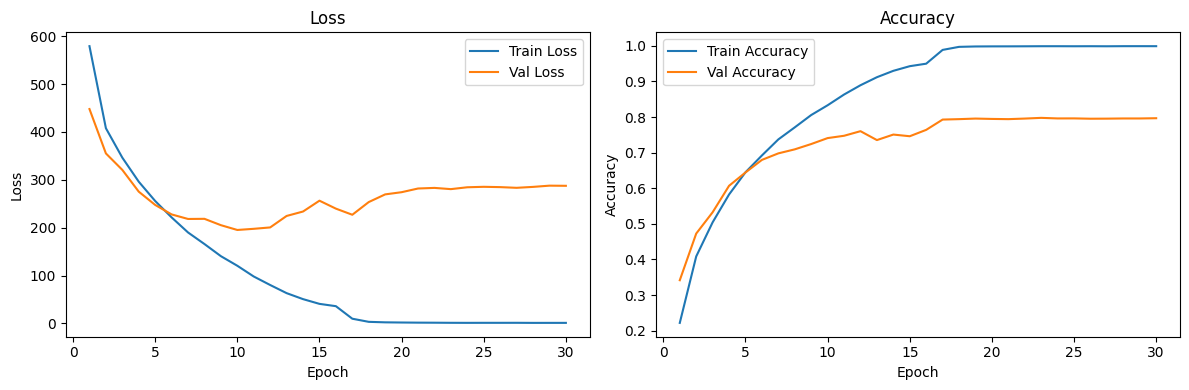

In [42]:
def main():
    model = ResNet(ResidualBlock, [3, 4, 6, 3])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=1e-1, weight_decay=1e-4, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5,
                                                           threshold=1e-4, cooldown=0, min_lr=1e-6)
    train_loader, test_loader = get_dataloaders(batch_size=256)

    train_loss, val_loss, train_acc, val_acc = train(
        model,
        train_loader,
        test_loader,
        criterion,
        optimizer,
        scheduler,
        num_epochs=30
    )

    print("Training completed!")

    plot_metrics(train_loss, val_loss, train_acc, val_acc)


if __name__ == "__main__":
    main()

Need sum data augmentations foo.